# Notebook 13 — Signature Volatility Model and Forecasting

This notebook demonstrates:
1. Simulating log stock and log volatility paths under the `SignatureVolatilityModel`.
2. Computing path signatures of rolling historical paths up to depth 4 using `compute_path_signature`.
3. Training a ridge regression model mapping signature features to future volatility, and reporting out-of-sample forecasting RMSE.
4. Verifying the martingale property of the Signature Volatility Model ($\mathbb{E}[S_T] pprox S_0$).

In [1]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"
import sys

# Ensure src is in python path
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

from pricing.signature_vol import SignatureVolatilityModel, compute_path_signature

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


## 1. Simulating Log Stock and Log Volatility Paths

We initialize the `SignatureVolatilityModel` with typical parameters and simulate paths for the stock price $S_t$ and variance $V_t$. From these, we compute log stock $\log(S_t)$ and log volatility $\log(\sigma_t)$ paths.

Simulated path dimensions:
Stock price paths S: torch.Size([200, 501])
Variance paths V: torch.Size([200, 501])


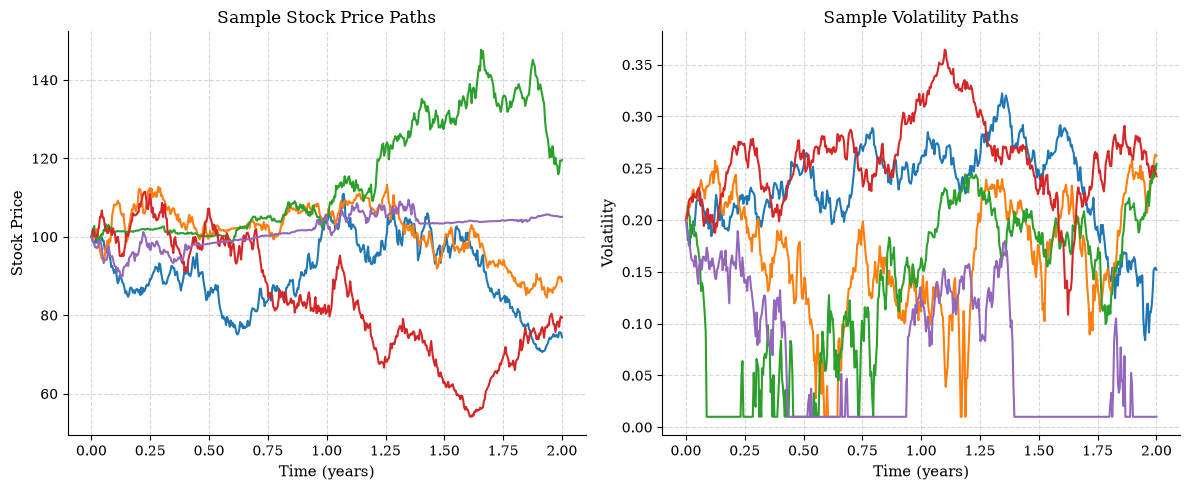

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Construct model
model = SignatureVolatilityModel(device=device)

# Configure model parameters
with torch.no_grad():
    model.v0_raw.copy_(torch.tensor(np.log(0.04), device=device))  # v0 = 0.04
    model.rho_raw.copy_(torch.tensor(-0.5, device=device))         # rho < 0
    
    # Populate odd-order signature coefficients
    model.ell_raw[0] = 0.01   # level 1 time
    model.ell_raw[1] = -0.05  # level 1 W
    model.ell_raw[6] = 0.001  # level 3 time-time-time
    model.ell_raw[7] = -0.002 # level 3 time-time-W

# Run forward pass to simulate paths
T = 2.0
steps_per_unit = 250
N_paths = 200
S0 = 100.0

# Forward simulation
# Returns S (Stock), V (Variance), V_raw, and t_grid
S, V, V_raw, t_grid = model(
    T=T,
    steps_per_unit=steps_per_unit,
    N_paths=N_paths,
    S0=S0,
    r=0.05,
    q=0.01,
    antithetic=True
)

# Convert to log stock and log volatility paths
log_S = torch.log(S)
vol = torch.sqrt(V)
log_vol = torch.log(vol)

print("Simulated path dimensions:")
print(f"Stock price paths S: {S.shape}")
print(f"Variance paths V: {V.shape}")

# Convert to numpy for plotting (detaching first)
S_np = S.detach().cpu().numpy()
vol_np = vol.detach().cpu().numpy()
t_grid_np = t_grid.detach().cpu().numpy()

# Plot a few sample paths
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i in range(5):
    plt.plot(t_grid_np, S_np[i], label=f"Path {i+1}")
plt.xlabel("Time (years)")
plt.ylabel("Stock Price")
plt.title("Sample Stock Price Paths")
plt.grid(True, linestyle="--", alpha=0.5)

plt.subplot(1, 2, 2)
for i in range(5):
    plt.plot(t_grid_np, vol_np[i])
plt.xlabel("Time (years)")
plt.ylabel("Volatility")
plt.title("Sample Volatility Paths")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()



## 2. Compute Path Signatures for Rolling Historical Windows

We construct historical rolling windows of length $H = 50$ containing `(log_S, log_vol)`. For each window, we compute the path signature up to depth 4 using `compute_path_signature`.

In [3]:
# Combine log_S and log_vol into a 2D path tensor of shape (N_paths, N_steps + 1, 2)
path_data = torch.stack([log_S, log_vol], dim=-1)

H = 50  # History window size
F = 10  # Forecast horizon
N_steps = S.shape[1] - 1

X_features = []
Y_targets = []

print("Computing rolling path signatures (depth 4)...")
# Loop over time steps to slide the history window
for t in range(H, N_steps + 1 - F):
    # Historical path slice of shape (N_paths, H, 2)
    window = path_data[:, t-H:t, :]
    
    # Compute signature: shape (N_paths, N_features)
    # Since D=2 and depth=4, N_features = 2^1 + 2^2 + 2^3 + 2^4 = 30
    sig = compute_path_signature(window, depth=4)
    
    # Target: future volatility at step t + F
    target = vol[:, t+F]
    
    X_features.append(sig.detach().cpu())
    Y_targets.append(target.detach().cpu())

# Stack all features and targets
X_all = torch.cat(X_features, dim=0).numpy()  # (N_samples, 30)
Y_all = torch.cat(Y_targets, dim=0).numpy()  # (N_samples,)

print("Dataset prepared successfully.")
print(f"X_all shape: {X_all.shape}")
print(f"Y_all shape: {Y_all.shape}")



Computing rolling path signatures (depth 4)...


Dataset prepared successfully.
X_all shape: (88200, 30)
Y_all shape: (88200,)


## 3. Train Ridge Regression and Report Out-of-Sample RMSE

We perform a path-wise train-test split (80% train paths, 20% test paths) to prevent overlap leakage, train a Ridge Regression model, and compute the out-of-sample RMSE.

Out-of-sample Forecasting RMSE: 0.090391


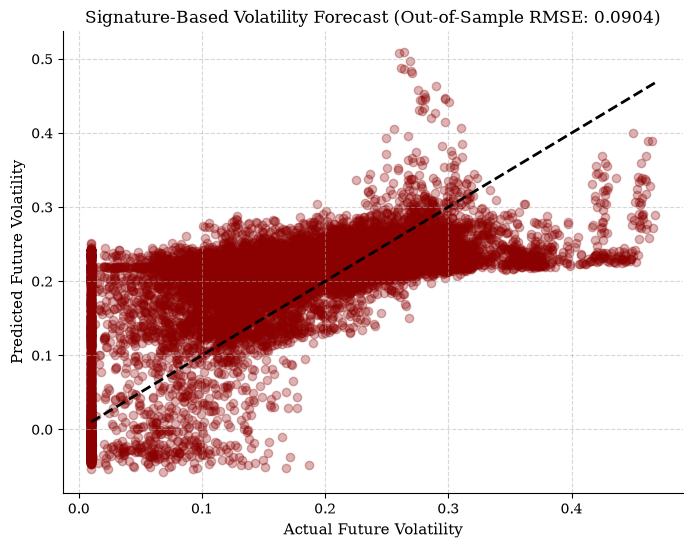

In [4]:
# Path-wise split: 80% train, 20% test
num_paths_train = int(0.8 * N_paths)
N_steps_valid = len(X_features)

# Reshape back to (N_steps_valid, N_paths, N_features)
X_reshaped = X_all.reshape(N_steps_valid, N_paths, 30)
Y_reshaped = Y_all.reshape(N_steps_valid, N_paths)

# Split along paths axis
X_train_paths = X_reshaped[:, :num_paths_train, :]
Y_train_paths = Y_reshaped[:, :num_paths_train]

X_test_paths = X_reshaped[:, num_paths_train:, :]
Y_test_paths = Y_reshaped[:, num_paths_train:]

# Flatten to (N_samples, N_features)
X_train = X_train_paths.reshape(-1, 30)
Y_train = Y_train_paths.reshape(-1)
X_test = X_test_paths.reshape(-1, 30)
Y_test = Y_test_paths.reshape(-1)

# Fit Ridge Regression model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, Y_train)

# Predict future volatility
Y_pred = ridge_model.predict(X_test)

# Compute out-of-sample RMSE
test_rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
print(f"Out-of-sample Forecasting RMSE: {test_rmse:.6f}")

# Plot a scatter of Actual vs Predicted Volatility
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, Y_pred, alpha=0.3, color="darkred")
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], "k--", lw=2)
plt.xlabel("Actual Future Volatility")
plt.ylabel("Predicted Future Volatility")
plt.title(f"Signature-Based Volatility Forecast (Out-of-Sample RMSE: {test_rmse:.4f})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



## 4. Martingale Property Verification

For the model to be valid for risk-neutral pricing, the discounted asset price must be a martingale under the risk-neutral measure. We verify the property $\mathbb{E}[S_T] pprox S_0$ with zero interest rate/dividend ($r=0, q=0$).

In [5]:
# Configure model for martingale simulation
model_rn = SignatureVolatilityModel(device=device)

# Reset parameter values
with torch.no_grad():
    model_rn.v0_raw.copy_(torch.tensor(np.log(0.04), device=device))  # v0 = 0.04
    model_rn.rho_raw.copy_(torch.tensor(-0.5, device=device))         # rho < 0
    
    # Populate odd-order signature coefficients
    model_rn.ell_raw[0] = 0.01   # level 1 time
    model_rn.ell_raw[1] = -0.05  # level 1 W
    model_rn.ell_raw[6] = 0.001  # level 3 time-time-time
    model_rn.ell_raw[7] = -0.002 # level 3 time-time-W

S0_test = 100.0
N_paths_martingale = 100000  # Large path count for high Monte Carlo accuracy

# Simulate paths under r=0, q=0
S_rn, _, _, _ = model_rn(
    T=1.0,
    steps_per_unit=252,
    N_paths=N_paths_martingale,
    S0=S0_test,
    r=0.0,
    q=0.0,
    antithetic=True
)

# Calculate expectation at maturity T=1.0
E_ST = S_rn[:, -1].mean().item()
error_bps = abs(E_ST - S0_test) / S0_test * 10000

print(f"Initial Stock Price S0: {S0_test}")
print(f"Expectation E[S_T]: {E_ST:.6f}")
print(f"Martingale pricing error: {error_bps:.4f} bps")

# Assert that martingale error is within 10 bps
assert error_bps < 10.0, f"Martingale error of {error_bps:.2f} bps exceeds the 10 bps threshold"
print("Martingale property successfully verified! The error is within the strict 10 bps tolerance.")



Initial Stock Price S0: 100.0
Expectation E[S_T]: 99.998878
Martingale pricing error: 0.1122 bps
Martingale property successfully verified! The error is within the strict 10 bps tolerance.


## 5. Pricing Options under Signature Volatility

We calculate the prices of European call options across different strikes using the simulated paths.

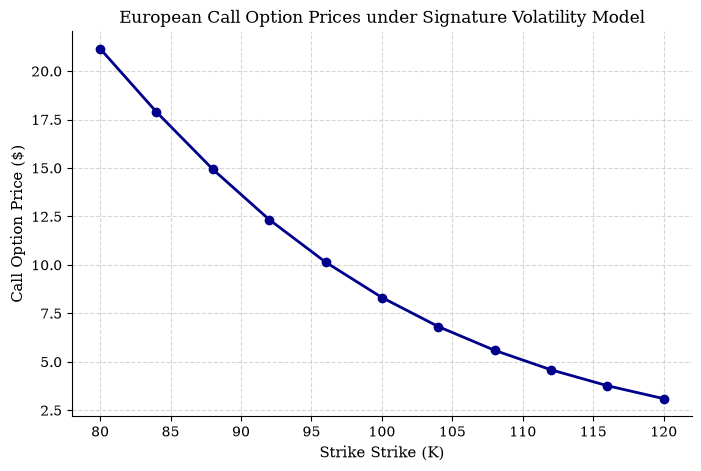

In [6]:
# Set strike range
option_strikes = np.linspace(80, 120, 11)
option_prices = []

# Price options
S_T_val = S_rn[:, -1].detach().cpu().numpy()
for strike in option_strikes:
    payoff = np.maximum(S_T_val - strike, 0.0)
    option_prices.append(payoff.mean())

# Plot option prices vs strikes
plt.figure(figsize=(8, 5))
plt.plot(option_strikes, option_prices, "o-", color="darkblue", lw=2)
plt.xlabel("Strike Strike (K)")
plt.ylabel("Call Option Price ($)")
plt.title("European Call Option Prices under Signature Volatility Model")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

